
# Transforma texto en embeddings

**Especialización en Inteligencia Artificial — Universidad de Cundinamarca**
**Curso:** Procesamiento de Lenguaje Natural
**Estudiante:** Jenifer Cárdenas Aguilera

**Basado en la serie *NLP Zero to Hero* (TensorFlow, Laurence Moroney):**
1. [Parte 1 — Tokenization](https://www.youtube.com/watch?v=fNxaJsNG3-s)
2. [Parte 2 — Sequencing: Turning sentences into data](https://www.youtube.com/watch?v=r9QjkdSJZ2g)
3. [Parte 3 — Training a model to recognize sentiment in text](https://www.youtube.com/watch?v=Y_hzMnRXjhI)
4. [Parte 4 — ML with Recurrent Neural Networks](https://www.youtube.com/watch?v=OuYtk9Ymut4)
5. [Parte 5 — Long Short-Term Memory for NLP](https://www.youtube.com/watch?v=A9QVYOBjZdY)
6. [Parte 6 — Training an AI to create poetry](https://www.youtube.com/watch?v=ZMudJXhsUpY)

In [31]:

# 0. Librerías necesarias
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences




## Parte 1 - Tokenización



In [32]:


frases = [
    'Me encanta mi perro',
    'Me encanta mi gato',
    'Tú amas a mi perro!',
    '¿Crees que mi perro es increíble?',
    'Amo a mis mascotas y a mi familia',
    'Quiero tener dos mascotas, un perro y un gato',
]

tokenizer = Tokenizer(num_words=50, oov_token="<OOV>")
tokenizer.fit_on_texts(frases)

word_index = tokenizer.word_index
print("Diccionario palabra -> número:")
print(word_index)

secuencias = tokenizer.texts_to_sequences(frases)
print("\nFrases convertidas a secuencias de números:")
for f, s in zip(frases, secuencias):
    print(f"{f!r:45} -> {s}")


Diccionario palabra -> número:
{'<OOV>': 1, 'mi': 2, 'perro': 3, 'a': 4, 'me': 5, 'encanta': 6, 'gato': 7, 'mascotas': 8, 'y': 9, 'un': 10, 'tú': 11, 'amas': 12, '¿crees': 13, 'que': 14, 'es': 15, 'increíble': 16, 'amo': 17, 'mis': 18, 'familia': 19, 'quiero': 20, 'tener': 21, 'dos': 22}

Frases convertidas a secuencias de números:
'Me encanta mi perro'                         -> [5, 6, 2, 3]
'Me encanta mi gato'                          -> [5, 6, 2, 7]
'Tú amas a mi perro!'                         -> [11, 12, 4, 2, 3]
'¿Crees que mi perro es increíble?'           -> [13, 14, 2, 3, 15, 16]
'Amo a mis mascotas y a mi familia'           -> [17, 4, 18, 8, 9, 4, 2, 19]
'Quiero tener dos mascotas, un perro y un gato' -> [20, 21, 22, 8, 10, 3, 9, 10, 7]


In [33]:

# Uso de <OOV>
frases_prueba = [
    'Mi perro se come mi tarea',
    'Mi gato es amigo de mi perro'
]
secuencias_prueba = tokenizer.texts_to_sequences(frases_prueba)
print(secuencias_prueba)
# 'se', 'come', 'tarea', 'es', 'amigo', 'de' no estaban en el corpus de entrenamiento
# -> todas se reemplazan por el número asignado a "<OOV>"


[[2, 3, 1, 1, 2, 1], [2, 7, 15, 1, 1, 2, 3]]



## Parte 2 - Secuencias y *Padding*




In [34]:

secuencias_padded = pad_sequences(secuencias, padding='pre', maxlen=10)
print("Secuencias con padding (largo automático = la frase más larga):\n")
print(secuencias_padded)

secuencias_padded_fijo = pad_sequences(secuencias, padding='post', maxlen=5, truncating='post')
print("\nSecuencias con padding y longitud fija (maxlen=5):\n")
print(secuencias_padded_fijo)


Secuencias con padding (largo automático = la frase más larga):

[[ 0  0  0  0  0  0  5  6  2  3]
 [ 0  0  0  0  0  0  5  6  2  7]
 [ 0  0  0  0  0 11 12  4  2  3]
 [ 0  0  0  0 13 14  2  3 15 16]
 [ 0  0 17  4 18  8  9  4  2 19]
 [ 0 20 21 22  8 10  3  9 10  7]]

Secuencias con padding y longitud fija (maxlen=5):

[[ 5  6  2  3  0]
 [ 5  6  2  7  0]
 [11 12  4  2  3]
 [13 14  2  3 15]
 [17  4 18  8  9]
 [20 21 22  8 10]]



## Parte 3 - De números a *Embeddings*



In [35]:

# Dataset de ejemplo: mini-reseñas en español etiquetadas como positivas (1) o negativas (0)
# (corpus sintético, generado combinando temas + valoraciones, sin necesidad de conexión a internet

temas = ["la película", "el producto", "el servicio", "el restaurante", "el libro", "la aplicación"]

valoraciones_positivas = [
    "me encantó, la actuación fue excelente",
    "superó todas mis expectativas, una experiencia maravillosa",
    "fue rápido y muy amable, totalmente recomendado",
    "es fascinante, no pude dejar de disfrutarlo",
    "excelente calidad, lo volvería a elegir sin dudarlo",
    "el equipo fue muy profesional y atento",
    "me sorprendió gratamente, una historia hermosa y bien contada",
    "estuvo brillante, disfruté cada minuto",
    "resolvieron mi problema de inmediato, muy buena atención",
    "el diseño es elegante y funciona perfectamente",
    "quedé feliz con el resultado, superó lo que esperaba",
    "es divertido, lo recomiendo a toda la familia",
    "el sabor es delicioso, definitivamente volvería a pedirlo",
    "la relación calidad precio es excelente",
    "está muy bien escrito y es muy original",
]

valoraciones_negativas = [
    "fue aburrido, me quedé dormida a la mitad",
    "es terrible, se dañó a los pocos días de uso",
    "fue lento y el personal fue grosero",
    "no tiene sentido, es confuso y está mal contado",
    "pésima calidad, no lo elegiría de nuevo",
    "fue una experiencia horrible, nadie resolvió mi reclamo",
    "fue decepcionante, esperaba mucho más",
    "estuvo flojo, no me convenció nada",
    "nunca respondieron mis mensajes, muy mala atención",
    "el diseño es feo y además no funciona bien",
    "quedé insatisfecha con el resultado, fue una pérdida de dinero",
    "es tedioso, no lo recomiendo para nada",
    "el sabor es desagradable, no volvería a pedirlo",
    "la relación calidad precio es pésima",
    "se siente forzado y aburrido, mal trabajo",
]

positivas = [f"{tema} {val}" for tema in temas for val in valoraciones_positivas]
negativas = [f"{tema} {val}" for tema in temas for val in valoraciones_negativas]

reviews = positivas + negativas
labels = [1] * len(positivas) + [0] * len(negativas)

print(f"Total de reseñas: {len(reviews)} ({len(positivas)} positivas, {len(negativas)} negativas)")
print("Ejemplo:", reviews[0], "->", labels[0])
print("Ejemplo:", reviews[-1], "->", labels[-1])


Total de reseñas: 180 (90 positivas, 90 negativas)
Ejemplo: la película me encantó, la actuación fue excelente -> 1
Ejemplo: la aplicación se siente forzado y aburrido, mal trabajo -> 0


In [36]:

# Separar en entrenamiento y prueba 
from sklearn.model_selection import train_test_split

train_sent, test_sent, train_labels, test_labels = train_test_split(
    reviews, labels, test_size=0.25, random_state=42, stratify=labels
)

print("Entrenamiento:", len(train_sent), "| Prueba:", len(test_sent))


Entrenamiento: 135 | Prueba: 45


In [37]:

# Tokenización + padding
vocab_size = 300
embedding_dim = 16
max_length = 12
trunc_type = 'post'
oov_tok = "<OOV>"

tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(train_sent)
word_index = tokenizer.word_index

train_sequences = tokenizer.texts_to_sequences(train_sent)
train_padded = pad_sequences(train_sequences, maxlen=max_length, truncating=trunc_type, padding='post')

test_sequences = tokenizer.texts_to_sequences(test_sent)
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating=trunc_type, padding='post')

train_labels = np.array(train_labels)
test_labels = np.array(test_labels)

print("Tamaño del vocabulario aprendido:", len(word_index))
print("Forma de train_padded:", train_padded.shape)


Tamaño del vocabulario aprendido: 130
Forma de train_padded: (135, 12)



### El modelo: `Embedding` + `GlobalAveragePooling1D` + `Dense`

- `Embedding(vocab_size, embedding_dim, input_length=max_length)`: crea la tabla de
  vectores (una fila por palabra del vocabulario) e inicialmente los llena con valores
  aleatorios pequeños. Estos vectores se ajustan durante el entrenamiento.
- `GlobalAveragePooling1D()`: promedia los vectores de todas las palabras de una frase
  para obtener **un solo vector por frase** (de tamaño `embedding_dim`).
- `Dense(6, activation='relu')` + `Dense(1, activation='sigmoid')`: la parte
  "clasificadora" normal, que aprende a decidir si ese vector promedio corresponde a un
  sentimiento positivo o negativo.


In [38]:

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


c:\Users\fefy3\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [39]:

num_epochs = 40
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy', patience=8, restore_best_weights=True
)

history = model.fit(
    train_padded, train_labels,
    epochs=num_epochs,
    validation_data=(test_padded, test_labels),
    callbacks=[early_stop],
    verbose=0
)
print("Entrenamiento terminado.")
print(f"Accuracy final (entrenamiento): {history.history['accuracy'][-1]:.3f}")
print(f"Accuracy final (validación):    {history.history['val_accuracy'][-1]:.3f}")


Entrenamiento terminado.
Accuracy final (entrenamiento): 1.000
Accuracy final (validación):    1.000


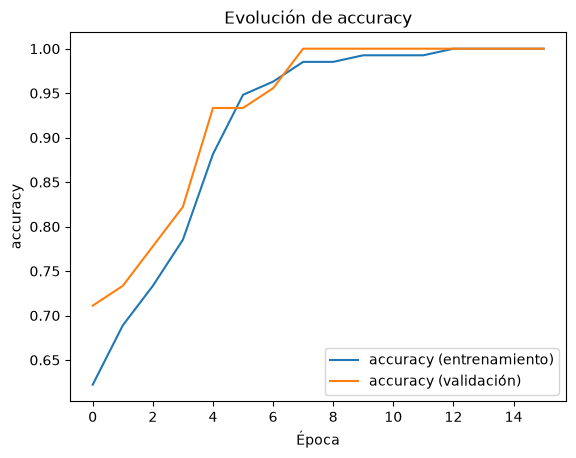

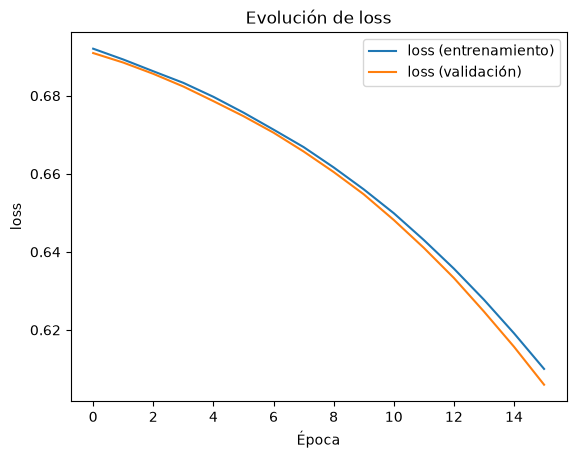

In [40]:

# Graficar la evolución del entrenamiento
def plot_history(history, metric):
    plt.plot(history.history[metric], label=f'{metric} (entrenamiento)')
    plt.plot(history.history[f'val_{metric}'], label=f'{metric} (validación)')
    plt.xlabel("Época")
    plt.ylabel(metric)
    plt.legend()
    plt.title(f"Evolución de {metric}")
    plt.show()

plot_history(history, "accuracy")
plot_history(history, "loss")


## Parte 4 — Redes neuronales recurrentes (RNN)
Una **Red Neuronal Recurrente (RNN)** procesa la frase palabra por palabra, en orden, y
mantiene un "estado" (memoria interna) que se va actualizando con cada palabra nueva. Así,
la representación final de la frase sí depende del orden en que aparecieron las palabras.


In [41]:
model_rnn = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.SimpleRNN(16)),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model_rnn.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


## Parte 5 — LSTM (Long Short-Term Memory)

Las RNN simples tienen un problema práctico: cuando una frase es larga, la información de
las primeras palabras tiende a "diluirse" antes de llegar al final (el llamado problema
del **gradiente que desaparece**). Las celdas **LSTM** resuelven esto agregando "puertas"
(*gates*) que deciden explícitamente qué información conservar, cuál olvidar y cuál dejar
pasar hacia la salida. En la práctica, una LSTM suele recordar mejor relaciones que están
separadas por muchas palabras.

En Keras, basta con cambiar `SimpleRNN` por `LSTM`; el resto de la arquitectura es
idéntico, lo que hace muy fácil comparar ambas.


In [42]:

# Mismo dataset y misma arquitectura, cambiando SimpleRNN por LSTM
model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(vocab_size, embedding_dim, input_length=max_length),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(16)),
    tf.keras.layers.Dense(6, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

history_lstm = model_lstm.fit(
    train_padded, train_labels,
    epochs=num_epochs,
    validation_data=(test_padded, test_labels),
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)],
    verbose=0
)
print("LSTM -> accuracy entrenamiento:", round(history_lstm.history['accuracy'][-1], 3),
      "| accuracy validación:", round(history_lstm.history['val_accuracy'][-1], 3))


LSTM -> accuracy entrenamiento: 1.0 | accuracy validación: 1.0



## Parte 6 - Generar texto: de clasificar a crear




In [43]:

# Corpus de ejemplo: versos cortos (texto original, escrito para esta práctica)
corpus_poesia = [
    "el rio corre entre las piedras del camino",
    "el viento canta bajo la luna llena",
    "las estrellas brillan sobre el mar en calma",
    "el sol despierta la montaña dormida",
    "la lluvia baila sobre el techo de zinc",
    "el fuego arde junto al viejo roble seco",
    "las hojas caen con el viento del otoño",
    "el camino sube hacia la montaña azul",
]

tokenizer_poesia = Tokenizer()
tokenizer_poesia.fit_on_texts(corpus_poesia)
total_palabras = len(tokenizer_poesia.word_index) + 1
print("Palabras distintas en el corpus:", total_palabras)

# Generar todas las secuencias de n-gramas, línea por línea
input_sequences = []
for linea in corpus_poesia:
    token_list = tokenizer_poesia.texts_to_sequences([linea])[0]
    for i in range(1, len(token_list)):
        input_sequences.append(token_list[:i+1])

print("Total de secuencias de entrenamiento generadas:", len(input_sequences))
print("Ejemplo de 3 secuencias:", input_sequences[:3])


Palabras distintas en el corpus: 44
Total de secuencias de entrenamiento generadas: 52
Ejemplo de 3 secuencias: [[1, 9], [1, 9, 10], [1, 9, 10, 11]]


In [44]:

# Padding + separar entrada (X) y etiqueta (y)
max_seq_len = max(len(seq) for seq in input_sequences)
input_sequences_padded = pad_sequences(input_sequences, maxlen=max_seq_len, padding='pre')

X = input_sequences_padded[:, :-1]
labels_y = input_sequences_padded[:, -1]
y = tf.keras.utils.to_categorical(labels_y, num_classes=total_palabras)

print("Forma de X (entradas):", X.shape)
print("Forma de y (etiquetas one-hot):", y.shape)


Forma de X (entradas): (52, 7)
Forma de y (etiquetas one-hot): (52, 44)


In [45]:


# Modelo generador: Embedding + LSTM bidireccional + Dense(softmax) sobre todo el vocabulario
#  Bidirectional(LSTM(150)), optimizador Adam con learning_rate=0.01 y 100 épocas)
model_gen = tf.keras.Sequential([
    tf.keras.layers.Embedding(total_palabras, 240, input_length=max_seq_len - 1),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(150)),
    tf.keras.layers.Dense(total_palabras, activation='softmax')
])

adam = tf.keras.optimizers.Adam(learning_rate=0.01)
model_gen.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])
history_gen = model_gen.fit(X, y, epochs=100, verbose=0)
print("Accuracy final generando la siguiente palabra:", round(history_gen.history['accuracy'][-1], 3))


Accuracy final generando la siguiente palabra: 0.904


In [46]:
# Generar texto nuevo, palabra por palabra
def generar_texto(texto_semilla, siguientes_palabras, modelo, tokenizer, max_seq_len):
    for _ in range(siguientes_palabras):
        token_list = tokenizer.texts_to_sequences([texto_semilla])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len - 1, padding='pre')
        probs = modelo.predict(token_list, verbose=0)[0]
        predicted_idx = np.argmax(probs)
        palabra_predicha = ""
        for palabra, idx in tokenizer.word_index.items():
            if idx == predicted_idx:
                palabra_predicha = palabra
                break
        texto_semilla += " " + palabra_predicha
    return texto_semilla

print(generar_texto("el rio corre", 6, model_gen, tokenizer_poesia, max_seq_len))
print(generar_texto("las estrellas", 6, model_gen, tokenizer_poesia, max_seq_len))
print(generar_texto("el viento", 8, model_gen, tokenizer_poesia, max_seq_len))


el rio corre entre las piedras del camino camino
las estrellas brillan sobre el mar en calma
el viento canta bajo la luna llena llena llena llena



## Conclusiones

- La tokenización convierte palabras en números; por sí sola no captura significado.
- El padding estandariza el largo de las secuencias para poder entrenar en lotes (batches).
- La capa `Embedding` aprende, junto con el resto de la red, una representación vectorial
  de cada palabra en la que la cercanía geométrica refleja cercanía semántica.


## Referencias

- Moroney, L. (TensorFlow). *NLP Zero to Hero*:
  [Parte 1](https://www.youtube.com/watch?v=fNxaJsNG3-s) ·
  [Parte 2](https://www.youtube.com/watch?v=r9QjkdSJZ2g) ·
  [Parte 3](https://www.youtube.com/watch?v=Y_hzMnRXjhI).
   [Parte 4](https://www.youtube.com/watch?v=OuYtk9Ymut4) ·
  [Parte 5](https://www.youtube.com/watch?v=A9QVYOBjZdY) ·
  [Parte 6](https://www.youtube.com/watch?v=ZMudJXhsUpY)
- Documentación oficial: `tf.keras.preprocessing.text.Tokenizer`,
  `tf.keras.layers.Embedding`.
- [TensorFlow Embedding Projector](https://projector.tensorflow.org/)
